## Space-time overlay

:class:`~skmap.overlay.SpaceTimeOverlay` slices the catalogue by date range
(via :meth:`~skmap.io.RasterData.filter_date`) and, for each range, samples
the matching raster layers at the point locations.  The result is a table
with the original columns plus one column per raster feature (season name).


## Setup

We start by importing the modules used in this tutorial.

In [1]:
import os

os.environ["PROJ_LIB"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"
os.environ["PROJ_DATA"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"

In [2]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from skmap.io import RasterData
from skmap.data import toy
from skmap.overlay import SpaceTimeOverlay

## Dataset

The toy dataset ships a set of **land-cover training points** (`samples.gpkg`) and a
few raster layers covering the same 256 x 256 grid (EPSG:3035):

- `static/elev` and `static/slope` — static terrain layers,
- `ndvi/filled` and `swir1` — quarterly Landsat composites (2014-2020).

Let's load the training points.

In [3]:
samples = toy.lc_samples()
samples.head()

,date,label,code,target,geometry
0,2019-01-01,Non-irrigated arable land,211,12,POINT (4027365.527 3213354.075)
1,2019-01-01,Non-irrigated arable land,211,12,POINT (4023031.781 3217702.786)
2,2019-01-01,Pastures,231,18,POINT (4025421.04 3210923.411)
3,2019-01-01,Road and rail networks and associated land,122,4,POINT (4027809.718 3215667.456)
4,2019-01-01,Pastures,231,18,POINT (4026861.747 3213664.458)


In [4]:
samples["label"].value_counts()

label
Pastures                                                                                  115
Non-irrigated arable land                                                                  30
Green urban areas                                                                          26
Broad-leaved forest                                                                        21
Sport and leisure facilities                                                               14
Road and rail networks and associated land                                                 10
Water courses                                                                               9
Discontinuous urban fabric                                                                  7
Industrial or commercial units                                                              7
Continuous urban fabric                                                                     5
Water bodies                                          

Each point has a `date` (used by the space-time overlay to pick the matching
temporal composite), a `label` (the land-cover class name), a `code` (CORINE code)
and a `target` (the integer class id we will predict).

## Building the catalog

A :class:`~skmap.io.RasterData` is loaded directly from the toy
`layers.yaml` catalogue via :meth:`~skmap.io.RasterData.from_yaml`.  The
catalogue expands the NDVI/SWIR-1 seasonal composites (with year-agnostic
season names) and the static terrain layers.  We keep the gap-filled NDVI
(`variant != 'gappy'`) and restrict the temporal layers to the full years
2015-2019.


In [5]:
rdata = (
    RasterData.from_yaml(str(toy.LAYERS_YAML), base_path=str(toy.DATA_DIR))
    .filter("variant != 'gappy'")
    .filter_date("2015-01-01", "2019-12-31", include_non_temporal=True, by_start_date=True)
)
rdata.get_groups()


{'common': ['elev', 'slope'], '2015': ['ndvi', 'swir1'], '2016': ['ndvi', 'swir1'], '2017': ['ndvi', 'swir1'], '2018': ['ndvi', 'swir1'], '2019': ['ndvi', 'swir1'], '2020': ['ndvi', 'swir1']}


## Space-time overlay

:class:`~skmap.overlay.SpaceTimeOverlay` groups the points by year (using the `date`
column) and, for each year, samples the matching raster layers at the point locations.
The result is a table with the original columns plus one column per raster feature.

In [15]:
rdata.info

In [8]:
overlay = SpaceTimeOverlay(
    points=samples,
    col_date="date",
    rasterdata=rdata,
    date_ranges=[(f"{y}-01-01", f"{y}-12-31") for y in range(2015, 2020)],
    raster_tiles=None,
    verbose=False,
)

train = overlay.run(max_ram_mb=512, out_file_name=None)
train.head()


Dropping 0 points out of 41 because out of extent
Dropping 0 points out of 37 because out of extent
Dropping 0 points out of 40 because out of extent
Dropping 0 points out of 43 because out of extent
Dropping 0 points out of 38 because out of extent
Dropping 0 points out of 57 because out of extent


,date,label,code,target,lon,lat,elev,slope,ndvi,swir1
0,2015-01-01,Pastures,231,18,4.024372e+06,3.214363e+06,58.0,43.0,84.0,51.0
1,2015-01-01,Pastures,231,18,4.020732e+06,3.212050e+06,57.0,33.0,77.0,34.0
2,2015-01-01,Broad-leaved forest,311,23,4.026238e+06,3.215984e+06,295.0,24.0,80.0,32.0
3,2015-01-01,Broad-leaved forest,311,23,4.027110e+06,3.216442e+06,163.0,16.0,84.0,37.0
4,2015-01-01,Water bodies,512,41,4.023718e+06,3.213876e+06,45.0,9.0,6.0,5.0


## Training

The overlaid table is a plain pandas DataFrame, so we can feed it directly to
scikit-learn. We use a random forest and evaluate it with 5-fold cross-validation.

In [20]:
#?LabelEncoder

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(train["target"].values)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

# Year-agnostic seasonal feature names (set by the layers.yaml ``name`` template).
features = [
    "ndvi_winter", "ndvi_spring", "ndvi_summer", "ndvi_fall",
    "swir1_winter", "swir1_spring", "swir1_summer", "swir1_fall",
    "elev", "slope",
]
X = train[features]

clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)


Let's inspect the per-class metrics.

In [11]:
y_pred = cross_val_predict(clf, X, y, cv=5)

print("Cross-validated classification report")
print(classification_report(y, y_pred))

Cross-validated classification report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.40      0.57      0.47         7
           2       0.00      0.00      0.00         7
           3       0.67      0.60      0.63        10
           4       0.54      0.58      0.56        26
           5       0.40      0.29      0.33        14
           6       0.72      0.77      0.74        30
           7       0.88      0.91      0.90       115
           8       0.00      0.00      0.00         1
           9       0.62      0.76      0.68        21
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         4
          12       0.78      0.78      0.78         9
          13       0.33      0.25      0.29         4

    accuracy                           0.71       256
   macro avg       0.38      0.39      0.38       256
weighted avg       0.68      0.71      0.6

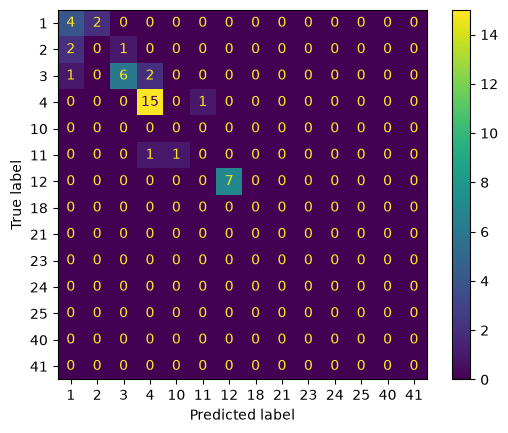

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y, y_pred, labels=le.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()

Now, we train the final model:

In [13]:
clf.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

## Predictions (mapping)

To produce a map we read the full raster grid for a single year, stack the
seasonal covariates in the model's feature order, predict every pixel and
reshape the result back to the 256 x 256 grid.


In [17]:
year = 2019

rdata_year = (
    RasterData.from_yaml(str(toy.LAYERS_YAML), base_path=str(toy.DATA_DIR))
    .filter("variant != 'gappy'")
    .filter_date(f"{year}-01-01", f"{year}-12-31", include_non_temporal=True, by_start_date=True)
    .read()
)

H, W = rdata_year._spatial_shape
arr = rdata_year.array.get()
idx = [rdata_year._band_index(f) for f in features]
stack = arr[idx, :].T.reshape(H, W, len(features))
pred_map = clf.predict(stack.reshape(-1, len(features))).reshape(H, W)
pred_map.shape


## Visualizing the map

Finally we plot the predicted land-cover map with
:func:`~skmap.plotter.plot_rasters`.

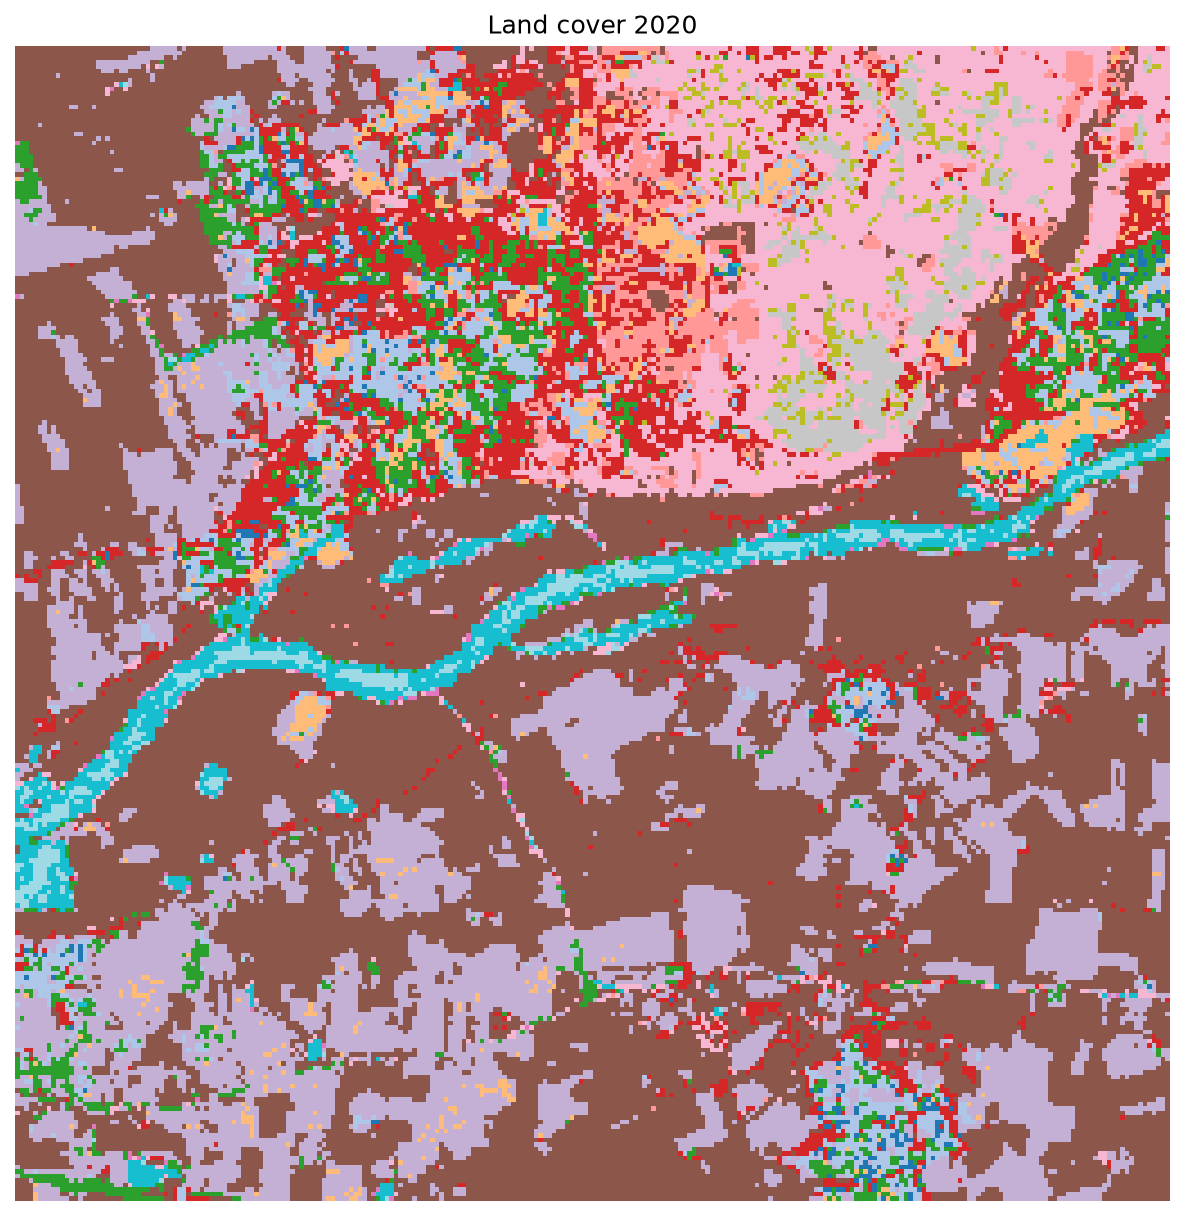

In [25]:
from skmap.plotter import plot_rasters
plot_rasters(pred_map, cmaps="tab20", titles=[f"Land cover {year}"])
